# UCL Location Tester

Load the saved 2-probe and 4-probe ResNet localisation models, choose real EIT contact samples whose target positions trace `UCL`, and plot the locations predicted by each model.

In [76]:
from pathlib import Path
import os
import re
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from matplotlib.collections import LineCollection
from matplotlib.patches import Polygon
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.textpath import TextPath
from matplotlib.transforms import Affine2D
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEXT_TO_DRAW = "UCL"
TEXT_POINT_MODE = "centerline"  # "filled" or "centerline"
N_TEXT_POINTS = 260
TEXT_FILL_GRID_RESOLUTION = 70
TEXT_LETTER_SPACING = 0.65
TRAPEZIUM_LEFT_HEIGHT_MM = 20.0
TRAPEZIUM_RIGHT_HEIGHT_MM = 15.0
TRAPEZIUM_GAP_MM = 60.0
FORCE_PREFERENCE_N = 3.0
SAVE_TRAPEZIUM_INTERIOR_PNG = True
TRAPEZIUM_INTERIOR_PNG_NAME = "location_tester_trapezium_inside.png"
TRAPEZIUM_MEASURED_PNG_NAME = "location_tester_trapezium_inside_measured.png"
SAVE_LOCATION_DIAGNOSTIC_PLOTS = True
LOCATION_DIAGNOSTIC_PLOT_NAME = "location_tester_real_vs_predicted_xy_distance"
LOCATION_DIAGNOSTIC_ERROR_CMAP = "viridis"
LOCATION_DIAGNOSTIC_ERROR_VMAX_PERCENTILE = 95.0

def find_used_data_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "RawData" / "UsedData",
        Path.cwd().parent / "RawData" / "UsedData",
    ]
    for candidate in candidates:
        if (candidate / "2Probe.csv").exists() and (candidate / "4Probe.csv").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find RawData/UsedData with 2Probe.csv and 4Probe.csv.")

USED_DATA_DIR = find_used_data_dir()
FIGURES_DIR = (USED_DATA_DIR / ".." / ".." / "Figures").resolve()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using data folder: {USED_DATA_DIR}")
print(f"Using figures folder: {FIGURES_DIR}")

Using data folder: /home/dhruv/AdityaFinrayGripper/RawData/UsedData
Using figures folder: /home/dhruv/AdityaFinrayGripper/Figures


In [77]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, regularization_strength=0.001):
        super().__init__()
        self.dense1 = nn.Linear(in_channels, out_channels)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.dense2 = nn.Linear(out_channels, out_channels)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.shortcut = nn.Identity()
        if in_channels != out_channels:
            self.shortcut = nn.Linear(in_channels, out_channels)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.dense1(x)))
        out = self.bn2(self.dense2(out))
        return self.relu(out + self.shortcut(residual))


class ResNetRegression(nn.Module):
    def __init__(self, input_dim, filters=64, regularization_strength=0.001):
        super().__init__()
        self.initial_dense = nn.Linear(input_dim, filters)
        self.initial_bn = nn.BatchNorm1d(filters)
        self.relu = nn.ReLU()
        self.block1 = ResNetBlock(filters, filters, regularization_strength)
        self.block2 = ResNetBlock(filters, filters * 2, regularization_strength)
        self.block3 = ResNetBlock(filters * 2, filters * 2, regularization_strength)
        self.output_layer = nn.Linear(filters * 2, 2)

    def forward(self, x):
        x = self.relu(self.initial_bn(self.initial_dense(x)))
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.output_layer(x)


def load_state_dict(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def load_resnet_model(path):
    state_dict = load_state_dict(path)
    input_dim = state_dict["initial_dense.weight"].shape[1]
    model = ResNetRegression(input_dim=input_dim).to(DEVICE)
    model.load_state_dict(state_dict)
    model.eval()
    return model, input_dim


def find_model_path(probe_label):
    if probe_label == "2-probe":
        candidates = [USED_DATA_DIR / "resnet_regression_model_2_probe.pth"]
    else:
        candidates = [USED_DATA_DIR / "resnet_regression_model_4_probe.pth"]
    for path in candidates:
        if path.exists():
            return path
    return None

In [78]:
def load_processed_contacts(csv_path):
    df = pd.read_csv(csv_path)
    df = df.iloc[1:].reset_index(drop=True)
    df = df.rename(columns={"eit_time_s": "time_eit_s"})
    df = df.drop(
        columns=["actual_x_mm", "actual_y_mm", "position_time_s", "force_time_s", "measurement_index"],
        errors="ignore",
    )
    eit_columns = [col for col in df.columns if re.fullmatch(r"eit_\d+", col)]
    eit_columns = sorted(eit_columns, key=lambda name: int(name.split("_")[1]))

    baseline = df[df["row_type"] == "baseline"].reset_index(drop=True)
    contact = df[df["row_type"] == "contact"].reset_index(drop=True)
    n_pairs = min(len(baseline), len(contact))
    baseline = baseline.iloc[:n_pairs].copy()
    contact = contact.iloc[:n_pairs].copy()

    contact.loc[:, eit_columns] = contact[eit_columns].to_numpy() - baseline[eit_columns].to_numpy()
    processed = contact.drop(columns=["row_type"], errors="ignore").copy()
    processed = processed.dropna(subset=["target_x_mm", "target_y_mm", *eit_columns]).reset_index(drop=True)

    scaler = StandardScaler()
    scaled_eit = scaler.fit_transform(processed[eit_columns])
    return processed, eit_columns, scaled_eit, scaler


datasets = {
    "2-probe": load_processed_contacts(USED_DATA_DIR / "2Probe.csv"),
    "4-probe": load_processed_contacts(USED_DATA_DIR / "4Probe.csv"),
}

for name, (df_contacts, eit_columns, scaled_eit, scaler) in datasets.items():
    print(f"{name}: {len(df_contacts)} contacts, {len(eit_columns)} EIT channels")

2-probe: 4800 contacts, 64 EIT channels
4-probe: 16000 contacts, 208 EIT channels


Generated 260 target points for 'centerline' text 'UCL'.


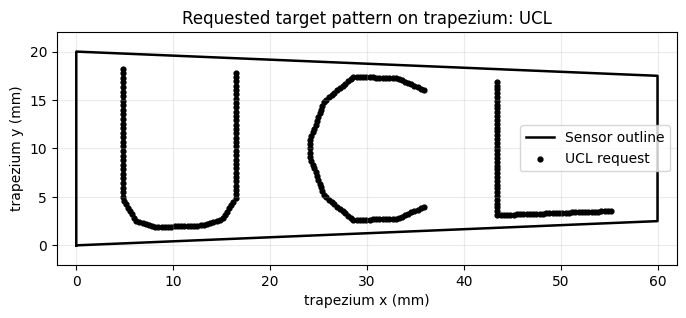

In [79]:
def sample_polyline(points, n_samples):
    points = np.asarray(points, dtype=float)
    if len(points) < 2:
        return points
    segment_lengths = np.linalg.norm(np.diff(points, axis=0), axis=1)
    total_length = segment_lengths.sum()
    if total_length == 0:
        return np.repeat(points[:1], n_samples, axis=0)
    cumulative = np.concatenate([[0.0], np.cumsum(segment_lengths)])
    distances = np.linspace(0, total_length, n_samples)
    sampled = []
    for distance in distances:
        segment_idx = np.searchsorted(cumulative, distance, side="right") - 1
        segment_idx = min(segment_idx, len(segment_lengths) - 1)
        start = points[segment_idx]
        end = points[segment_idx + 1]
        length = segment_lengths[segment_idx]
        t = 0.0 if length == 0 else (distance - cumulative[segment_idx]) / length
        sampled.append(start + t * (end - start))
    return np.asarray(sampled)


def make_spaced_text_paths(text, letter_spacing=0.65):
    glyph_paths = []
    glyph_widths = []
    for char in text:
        if char.isspace():
            continue
        glyph_path = TextPath((0, 0), char, size=1.0)
        bbox = glyph_path.get_extents()
        glyph_paths.append((char, glyph_path, bbox))
        glyph_widths.append(max(float(bbox.width), 1e-9))
    if not glyph_paths:
        raise ValueError(f"Could not make glyphs for text {text!r}.")

    average_width = float(np.mean(glyph_widths))
    gap = letter_spacing * average_width
    cursor_x = 0.0
    spaced_paths = []
    for char in text:
        if char.isspace():
            cursor_x += average_width + gap
            continue
        for i, (candidate_char, glyph_path, bbox) in enumerate(glyph_paths):
            if candidate_char == char:
                glyph_paths.pop(i)
                break
        shift_x = cursor_x - float(bbox.xmin)
        spaced_path = Affine2D().translate(shift_x, 0.0).transform_path(glyph_path)
        spaced_paths.append(spaced_path)
        cursor_x += max(float(bbox.width), 1e-9) + gap
    return spaced_paths


def scale_text_points_to_bounds(points, x_bounds, y_bounds, margin_fraction=0.08):
    points = np.asarray(points, dtype=float)
    min_xy = points.min(axis=0)
    max_xy = points.max(axis=0)
    span = np.maximum(max_xy - min_xy, 1e-9)
    normalized = (points - min_xy) / span

    x_min, x_max = x_bounds
    y_min, y_max = y_bounds
    x_margin = (x_max - x_min) * margin_fraction
    y_margin = (y_max - y_min) * margin_fraction
    return np.column_stack([
        x_min + x_margin + normalized[:, 0] * (x_max - x_min - 2 * x_margin),
        y_min + y_margin + normalized[:, 1] * (y_max - y_min - 2 * y_margin),
    ])


def make_centerline_letter_polylines(text, letter_spacing=0.65):
    stroke_templates = {
        "U": [np.array([[0.0, 1.0], [0.0, 0.18], [0.12, 0.04], [0.28, 0.0], [0.50, 0.0], [0.72, 0.0], [0.88, 0.04], [1.0, 0.18], [1.0, 1.0]])],
        "C": [np.array([[1.0, 0.92], [0.78, 1.0], [0.38, 1.0], [0.12, 0.82], [0.0, 0.56], [0.0, 0.44], [0.12, 0.18], [0.38, 0.0], [0.78, 0.0], [1.0, 0.08]])],
        "L": [np.array([[0.0, 1.0], [0.0, 0.0], [1.0, 0.0]])],
    }
    cursor_x = 0.0
    polylines = []
    gap = float(letter_spacing)
    for char in text.upper():
        if char.isspace():
            cursor_x += 1.0 + gap
            continue
        if char not in stroke_templates:
            raise ValueError(f"Centerline mode currently has a stroke template for U, C, and L only; got {char!r}.")
        for polyline in stroke_templates[char]:
            shifted = polyline.copy()
            shifted[:, 0] += cursor_x
            polylines.append(shifted)
        cursor_x += 1.0 + gap
    return polylines


def make_centerline_text_points(text, x_bounds, y_bounds, n_points=260, letter_spacing=0.65, margin_fraction=0.08):
    polylines = make_centerline_letter_polylines(text, letter_spacing=letter_spacing)
    lengths = np.array([np.linalg.norm(np.diff(polyline, axis=0), axis=1).sum() for polyline in polylines])
    counts = np.maximum(2, np.round(n_points * lengths / lengths.sum()).astype(int))
    points = np.vstack([sample_polyline(polyline, count) for polyline, count in zip(polylines, counts)])
    return scale_text_points_to_bounds(points, x_bounds, y_bounds, margin_fraction=margin_fraction)


def make_filled_text_points(text, x_bounds, y_bounds, n_points=260, fill_grid_resolution=70, letter_spacing=0.65, margin_fraction=0.08):
    text_paths = make_spaced_text_paths(text, letter_spacing=letter_spacing)
    polygons = [poly for path in text_paths for poly in path.to_polygons() if len(poly) > 1]
    if not polygons:
        raise ValueError(f"Could not make polygons for text {text!r}.")

    lengths = np.array([np.linalg.norm(np.diff(poly, axis=0), axis=1).sum() for poly in polygons])
    counts = np.maximum(2, np.round(n_points * lengths / lengths.sum()).astype(int))
    outline_points = np.vstack([sample_polyline(poly, count) for poly, count in zip(polygons, counts)])

    all_vertices = np.vstack([path.vertices for path in text_paths])
    bbox_xmin, bbox_ymin = all_vertices.min(axis=0)
    bbox_xmax, bbox_ymax = all_vertices.max(axis=0)
    width = max(float(bbox_xmax - bbox_xmin), 1e-9)
    height = max(float(bbox_ymax - bbox_ymin), 1e-9)
    x_grid = np.linspace(float(bbox_xmin), float(bbox_xmax), fill_grid_resolution)
    y_grid_count = max(2, int(round(fill_grid_resolution * height / width)))
    y_grid = np.linspace(float(bbox_ymin), float(bbox_ymax), y_grid_count)
    xx, yy = np.meshgrid(x_grid, y_grid)
    grid_points = np.column_stack([xx.ravel(), yy.ravel()])
    inside_any_glyph = np.zeros(len(grid_points), dtype=bool)
    for path in text_paths:
        inside_any_glyph |= path.contains_points(grid_points)
    interior_points = grid_points[inside_any_glyph]

    if len(interior_points):
        points = np.vstack([outline_points, interior_points])
        points = np.unique(np.round(points, 6), axis=0)
    else:
        points = outline_points

    return scale_text_points_to_bounds(points, x_bounds, y_bounds, margin_fraction=margin_fraction)


def make_text_points(text, x_bounds, y_bounds, mode="filled", n_points=260, fill_grid_resolution=70, letter_spacing=0.65, margin_fraction=0.08):
    mode = mode.lower().strip()
    if mode == "filled":
        return make_filled_text_points(
            text,
            x_bounds,
            y_bounds,
            n_points=n_points,
            fill_grid_resolution=fill_grid_resolution,
            letter_spacing=letter_spacing,
            margin_fraction=margin_fraction,
        )
    if mode in {"centerline", "centreline", "line"}:
        return make_centerline_text_points(
            text,
            x_bounds,
            y_bounds,
            n_points=n_points,
            letter_spacing=letter_spacing,
            margin_fraction=margin_fraction,
        )
    raise ValueError("TEXT_POINT_MODE must be 'filled' or 'centerline'.")


def trapezium_y_bounds(x_mesh):
    t = np.asarray(x_mesh, dtype=float) / TRAPEZIUM_GAP_MM
    height = (1.0 - t) * TRAPEZIUM_LEFT_HEIGHT_MM + t * TRAPEZIUM_RIGHT_HEIGHT_MM
    centre_y = TRAPEZIUM_LEFT_HEIGHT_MM / 2.0
    bottom = centre_y - height / 2.0
    top = centre_y + height / 2.0
    return bottom, top


def map_points_to_trapezium(points, x_bounds, y_bounds):
    points = np.asarray(points, dtype=float)
    x_min, x_max = x_bounds
    y_min, y_max = y_bounds
    x_norm = (points[:, 0] - x_min) / max(float(x_max - x_min), 1e-9)
    y_norm = (points[:, 1] - y_min) / max(float(y_max - y_min), 1e-9)
    x_mesh = x_norm * TRAPEZIUM_GAP_MM
    bottom, top = trapezium_y_bounds(x_mesh)
    y_mesh = bottom + y_norm * (top - bottom)
    return np.column_stack([x_mesh, y_mesh])


def draw_trapezium_outline(ax):
    x = np.array([0.0, TRAPEZIUM_GAP_MM])
    bottom, top = trapezium_y_bounds(x)
    outline_x = [0.0, TRAPEZIUM_GAP_MM, TRAPEZIUM_GAP_MM, 0.0, 0.0]
    outline_y = [bottom[0], bottom[1], top[1], top[0], bottom[0]]
    ax.plot(outline_x, outline_y, color="black", linewidth=1.8, label="Sensor outline")
    ax.set_xlim(-2.0, TRAPEZIUM_GAP_MM + 2.0)
    ax.set_ylim(min(bottom.min(), top.min()) - 2.0, max(bottom.max(), top.max()) + 2.0)


reference_df = datasets["2-probe"][0]
x_bounds = (reference_df["target_x_mm"].min(), reference_df["target_x_mm"].max())
y_bounds = (reference_df["target_y_mm"].min(), reference_df["target_y_mm"].max())
ucl_target_points = make_text_points(
    TEXT_TO_DRAW,
    x_bounds,
    y_bounds,
    mode=TEXT_POINT_MODE,
    n_points=N_TEXT_POINTS,
    fill_grid_resolution=TEXT_FILL_GRID_RESOLUTION,
    letter_spacing=TEXT_LETTER_SPACING,
)
print(f"Generated {len(ucl_target_points)} target points for {TEXT_POINT_MODE!r} text {TEXT_TO_DRAW!r}.")

ucl_trapezium_points = map_points_to_trapezium(ucl_target_points, x_bounds, y_bounds)

fig, ax = plt.subplots(figsize=(8, 4.5))
draw_trapezium_outline(ax)
ax.scatter(ucl_trapezium_points[:, 0], ucl_trapezium_points[:, 1], s=12, c="black", label="UCL request")
ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Requested target pattern on trapezium: {TEXT_TO_DRAW}")
ax.set_xlabel("trapezium x (mm)")
ax.set_ylabel("trapezium y (mm)")
ax.legend(loc="best")
ax.grid(True, alpha=0.25)
plt.show()

In [80]:
def choose_nearest_real_samples(df_contacts, scaled_eit, target_points, force_preference=3.0):
    locations = df_contacts[["target_x_mm", "target_y_mm"]].to_numpy(dtype=float)
    force = df_contacts.get("target_force_N", pd.Series(np.nan, index=df_contacts.index)).to_numpy(dtype=float)
    selected_indices = []
    x_range = max(np.ptp(locations[:, 0]), 1.0)
    y_range = max(np.ptp(locations[:, 1]), 1.0)

    for point in target_points:
        spatial_distance = ((locations[:, 0] - point[0]) / x_range) ** 2 + ((locations[:, 1] - point[1]) / y_range) ** 2
        best_location_distance = spatial_distance.min()
        same_location = np.isclose(spatial_distance, best_location_distance)
        force_penalty = np.zeros_like(spatial_distance)
        if np.isfinite(force).any():
            force_penalty = np.abs(np.nan_to_num(force, nan=force_preference) - force_preference) / 1000.0
        score = spatial_distance + force_penalty
        score[~same_location] = np.inf
        selected_indices.append(int(np.argmin(score)))

    selected_indices = np.asarray(selected_indices, dtype=int)
    selected = df_contacts.iloc[selected_indices].reset_index(drop=True)
    selected_scaled_eit = scaled_eit[selected_indices]
    return selected, selected_scaled_eit, selected_indices


def predict_locations(model, scaled_eit):
    with torch.no_grad():
        tensor = torch.tensor(scaled_eit, dtype=torch.float32, device=DEVICE)
        return model(tensor).cpu().numpy()


results = {}
for probe_label, dataset in datasets.items():
    df_contacts, eit_columns, scaled_eit, scaler = dataset
    model_path = find_model_path(probe_label)
    if model_path is None:
        warnings.warn(f"No saved {probe_label} ResNet model found in {USED_DATA_DIR}.")
        continue

    model, input_dim = load_resnet_model(model_path)
    if input_dim != len(eit_columns):
        warnings.warn(
            f"Skipping {probe_label}: model expects {input_dim} channels, "
            f"but {len(eit_columns)} columns were found in the CSV."
        )
        continue

    selected_rows, selected_scaled_eit, selected_indices = choose_nearest_real_samples(
        df_contacts, scaled_eit, ucl_target_points, FORCE_PREFERENCE_N
    )
    predictions = predict_locations(model, selected_scaled_eit)
    results[probe_label] = {
        "model_path": model_path,
        "selected_rows": selected_rows,
        "selected_indices": selected_indices,
        "predictions": predictions,
    }
    print(f"{probe_label}: predicted {len(predictions)} UCL points with {model_path.name}")

if not results:
    raise RuntimeError("No compatible ResNet models were found to test.")

2-probe: predicted 260 UCL points with resnet_regression_model_2_probe.pth
4-probe: predicted 260 UCL points with resnet_regression_model_4_probe.pth


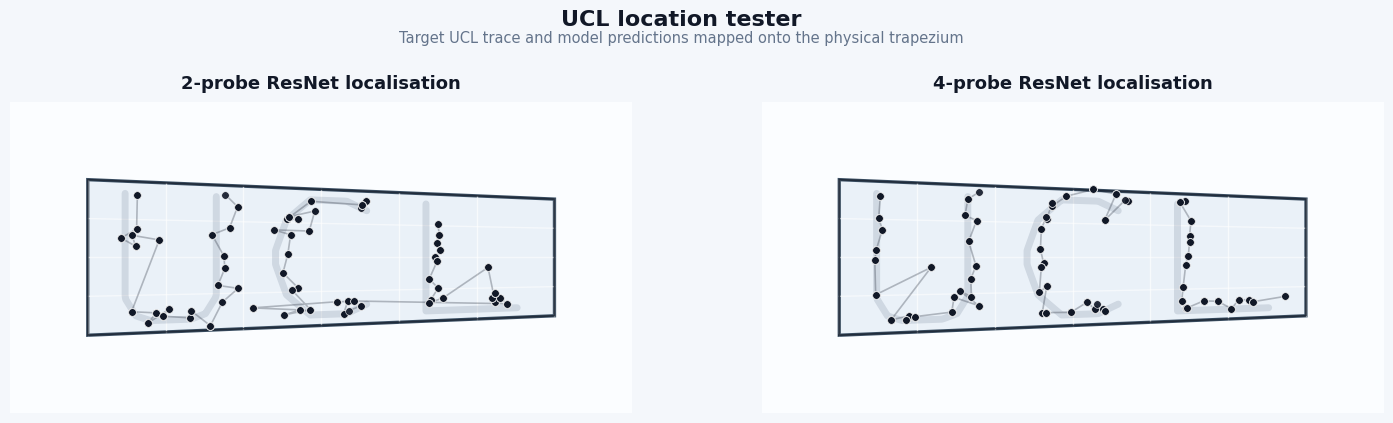

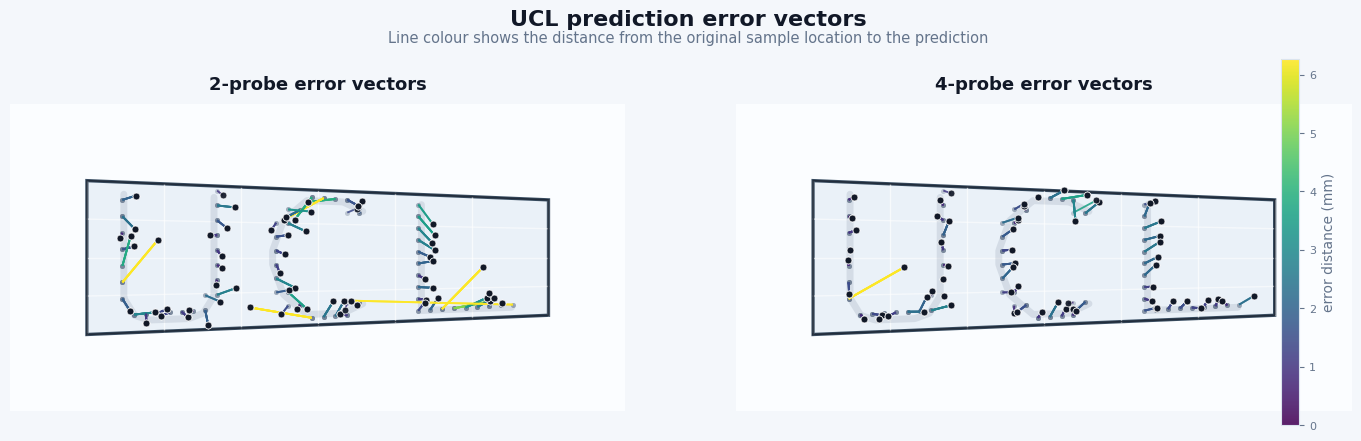

Diagnostic heatmaps use viridis with a shared 0-6.26 mm scale (95th percentile); larger errors are saturated.


<Figure size 640x480 with 0 Axes>

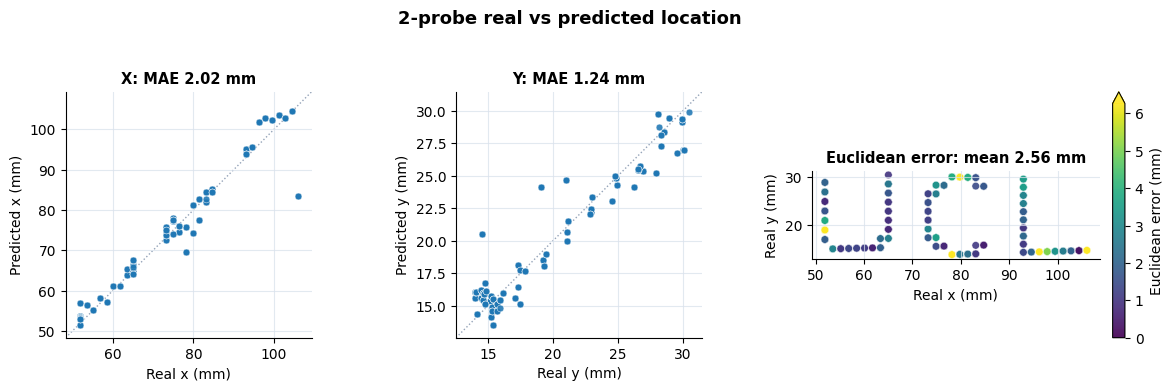

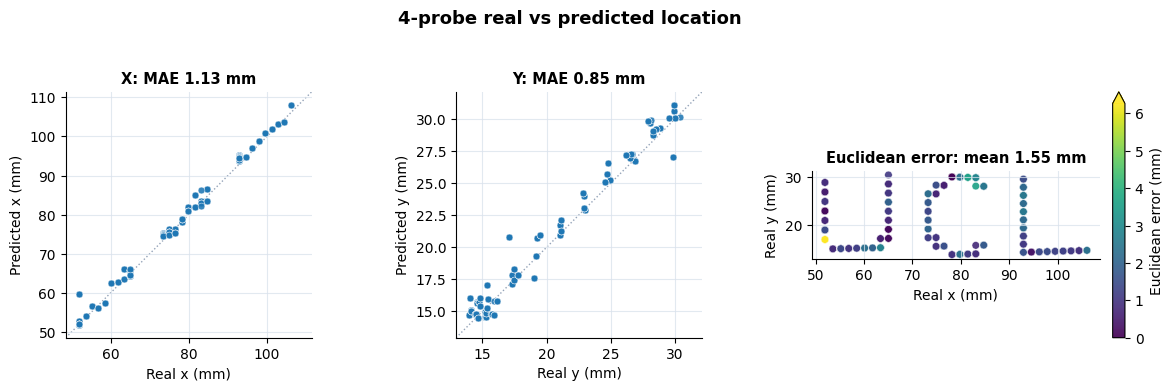

Saved real-vs-predicted diagnostic plot(s):
  /home/dhruv/AdityaFinrayGripper/Figures/location_tester_real_vs_predicted_xy_distance_2_probe.png
  /home/dhruv/AdityaFinrayGripper/Figures/location_tester_real_vs_predicted_xy_distance_2_probe.svg
  /home/dhruv/AdityaFinrayGripper/Figures/location_tester_real_vs_predicted_xy_distance_4_probe.png
  /home/dhruv/AdityaFinrayGripper/Figures/location_tester_real_vs_predicted_xy_distance_4_probe.svg
Saved trapezium-only PNG(s):
  /home/dhruv/AdityaFinrayGripper/Figures/location_tester_trapezium_inside_2_probe.png
  /home/dhruv/AdityaFinrayGripper/Figures/location_tester_trapezium_inside_measured_2_probe.png
  /home/dhruv/AdityaFinrayGripper/Figures/location_tester_trapezium_inside_4_probe.png
  /home/dhruv/AdityaFinrayGripper/Figures/location_tester_trapezium_inside_measured_4_probe.png
Saved trapezium-only SVG(s):
  /home/dhruv/AdityaFinrayGripper/Figures/location_tester_trapezium_inside_2_probe.png
  /home/dhruv/AdityaFinrayGripper/Figures/loc

In [81]:
STYLE = {
    "figure_bg": "#f4f7fb",
    "panel_bg": "#fbfdff",
    "outline": "#1f2937",
    "sensor_fill": "#eaf1f8",
    "sensor_edge": "#34495e",
    "request": "#64748b",
    "prediction": "#111827",
    "measured": "#475569",
    "prediction_edge": "#7f1d1d",
    "path": "#ef4444",
    "grid": "#cbd5e1",
    "text": "#111827",
    "muted": "#64748b",
}


def get_trapezium_outline_points():
    x = np.array([0.0, TRAPEZIUM_GAP_MM])
    bottom, top = trapezium_y_bounds(x)
    return np.array([
        [0.0, bottom[0]],
        [TRAPEZIUM_GAP_MM, bottom[1]],
        [TRAPEZIUM_GAP_MM, top[1]],
        [0.0, top[0]],
    ])


def draw_sensor_panel(ax):
    outline = get_trapezium_outline_points()
    ax.add_patch(
        Polygon(
            outline,
            closed=True,
            facecolor=STYLE["sensor_fill"],
            edgecolor=STYLE["sensor_edge"],
            linewidth=2.4,
            alpha=0.96,
            zorder=0,
        )
    )

    xs = np.linspace(0.0, TRAPEZIUM_GAP_MM, 7)
    bottom, top = trapezium_y_bounds(xs)
    for x_val, y0, y1 in zip(xs, bottom, top):
        ax.plot([x_val, x_val], [y0, y1], color="white", linewidth=1.0, alpha=0.65, zorder=1)

    for fraction in np.linspace(0.25, 0.75, 3):
        y_line = bottom + fraction * (top - bottom)
        ax.plot(xs, y_line, color="white", linewidth=1.0, alpha=0.55, zorder=1)

    ax.plot(*np.vstack([outline, outline[0]]).T, color=STYLE["outline"], linewidth=1.2, alpha=0.9, zorder=2)
    ax.set_xlim(-3.0, TRAPEZIUM_GAP_MM + 3.0)
    ax.set_ylim(outline[:, 1].min() - 2.5, outline[:, 1].max() + 2.5)
    ax.set_facecolor(STYLE["panel_bg"])
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, color=STYLE["grid"], linewidth=0.8, alpha=0.35)
    ax.tick_params(colors=STYLE["muted"], labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)


def get_location_layers(result):
    selected_rows = result["selected_rows"]
    predictions = result["predictions"]
    measured_locations = selected_rows[["target_x_mm", "target_y_mm"]].to_numpy(dtype=float)
    measured_trapezium = map_points_to_trapezium(measured_locations, x_bounds, y_bounds)
    predicted_trapezium = map_points_to_trapezium(predictions, x_bounds, y_bounds)
    errors = np.linalg.norm(predictions - measured_locations, axis=1)
    sequence = np.arange(len(predicted_trapezium))
    return measured_trapezium, predicted_trapezium, errors, sequence


def add_metric_box(ax, errors, n_points):
    summary = (
        f"{n_points} points\n"
        f"mean {errors.mean():.2f} mm\n"
        f"median {np.median(errors):.2f} mm\n"
        f"max {errors.max():.2f} mm"
    )
    ax.text(
        0.985,
        0.045,
        summary,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        color=STYLE["text"],
        linespacing=1.35,
        bbox={
            "boxstyle": "round,pad=0.45,rounding_size=0.08",
            "facecolor": "white",
            "edgecolor": "#dbe4ee",
            "alpha": 0.92,
        },
        zorder=8,
    )


def plot_segmented_path(ax, points, jump_threshold_mm=4.0, **plot_kwargs):
    points = np.asarray(points, dtype=float)
    if len(points) < 2:
        return []
    jumps = np.linalg.norm(np.diff(points, axis=0), axis=1) > jump_threshold_mm
    split_indices = np.flatnonzero(jumps) + 1
    return plot_path_segments(ax, points, split_indices, **plot_kwargs)


def plot_path_segments(ax, points, split_indices, **plot_kwargs):
    points = np.asarray(points, dtype=float)
    segments = np.split(points, split_indices)
    lines = []
    for segment in segments:
        if len(segment) > 1:
            lines.extend(ax.plot(segment[:, 0], segment[:, 1], **plot_kwargs))
    return lines


def plot_location_result(ax, probe_label, result, add_colorbar=False):
    measured_trapezium, predicted_trapezium, errors, sequence = get_location_layers(result)

    draw_sensor_panel(ax)
    letter_split_indices = np.flatnonzero(np.linalg.norm(np.diff(ucl_trapezium_points, axis=0), axis=1) > 4.0) + 1
    plot_segmented_path(
        ax,
        ucl_trapezium_points,
        jump_threshold_mm=4.0,
        color=STYLE["request"],
        linewidth=5.0,
        alpha=0.20,
        solid_capstyle="round",
        zorder=3,
    )
    plot_path_segments(
        ax,
        predicted_trapezium,
        letter_split_indices,
        color=STYLE["prediction"],
        linewidth=1.2,
        alpha=0.28,
        zorder=6,
    )
    sc = ax.scatter(
        predicted_trapezium[:, 0],
        predicted_trapezium[:, 1],
        s=30,
        c=STYLE["prediction"],
        edgecolors="white",
        linewidths=0.45,
        alpha=0.90,
        zorder=7,
    )
    # ax.scatter(
    #     predicted_trapezium[0, 0],
    #     predicted_trapezium[0, 1],
    #     s=82,
    #     marker="o",
    #     facecolor="#22c55e",
    #     edgecolor="white",
    #     linewidth=1.2,
    #     label="Start",
    #     zorder=7,
    # )
    # ax.scatter(
    #     predicted_trapezium[-1, 0],
    #     predicted_trapezium[-1, 1],
    #     s=96,
    #     marker="X",
    #     facecolor="#2563eb",
    #     edgecolor="white",
    #     linewidth=1.2,
    #     label="End",
    #     zorder=7,
    # )

    ax.set_title(f"{probe_label} ResNet localisation", fontsize=13, fontweight="bold", color=STYLE["text"], pad=10)
    ax.set_ylim(-10.0, TRAPEZIUM_LEFT_HEIGHT_MM + 10.0)
    ax.set_xlim(-10.0, TRAPEZIUM_GAP_MM + 10.0)
    ax.grid(False)
    ax.tick_params(labelbottom=False, labelleft=False, length=0)

    if add_colorbar:
        cax = inset_axes(ax, width="2.6%", height="58%", loc="center right", borderpad=1.25)
        cbar = plt.colorbar(sc, cax=cax)
        cbar.set_label("draw order", color=STYLE["muted"], fontsize=8)
        cbar.ax.tick_params(labelsize=8, colors=STYLE["muted"])
        cbar.outline.set_edgecolor("#dbe4ee")

    return errors


def plot_error_vector_result(ax, probe_label, result, error_vmin, error_vmax):
    measured_trapezium, predicted_trapezium, errors, sequence = get_location_layers(result)
    segments = np.stack([measured_trapezium, predicted_trapezium], axis=1)

    draw_sensor_panel(ax)
    plot_segmented_path(
        ax,
        ucl_trapezium_points,
        jump_threshold_mm=4.0,
        color=STYLE["request"],
        linewidth=5.0,
        alpha=0.16,
        solid_capstyle="round",
        zorder=3,
    )
    ax.scatter(
        measured_trapezium[:, 0],
        measured_trapezium[:, 1],
        s=13,
        c=STYLE["request"],
        alpha=0.34,
        linewidths=0,
        zorder=4,
    )
    vectors = LineCollection(
        segments,
        cmap=LOCATION_DIAGNOSTIC_ERROR_CMAP,
        norm=plt.Normalize(vmin=error_vmin, vmax=error_vmax),
        linewidths=1.35,
        alpha=0.88,
        zorder=5,
    )
    vectors.set_array(errors)
    ax.add_collection(vectors)
    ax.scatter(
        predicted_trapezium[:, 0],
        predicted_trapezium[:, 1],
        s=24,
        c=STYLE["prediction"],
        edgecolors="white",
        linewidths=0.45,
        alpha=0.92,
        zorder=6,
    )

    ax.set_title(f"{probe_label} error vectors", fontsize=13, fontweight="bold", color=STYLE["text"], pad=10)
    ax.set_ylim(-10.0, TRAPEZIUM_LEFT_HEIGHT_MM + 10.0)
    ax.set_xlim(-10.0, TRAPEZIUM_GAP_MM + 10.0)
    ax.grid(False)
    ax.tick_params(labelbottom=False, labelleft=False, length=0)
    return vectors, errors


def add_identity_line(ax, values_a, values_b):
    finite = np.concatenate([values_a[np.isfinite(values_a)], values_b[np.isfinite(values_b)]])
    if len(finite) == 0:
        return
    low = float(finite.min())
    high = float(finite.max())
    pad = max((high - low) * 0.06, 1.0)
    ax.plot([low - pad, high + pad], [low - pad, high + pad], color="#94a3b8", linewidth=1.0, linestyle=":", zorder=1)
    ax.set_xlim(low - pad, high + pad)
    ax.set_ylim(low - pad, high + pad)


def plot_real_predicted_xy_distance(
    result, probe_label, output_stem=None, save=True, dpi=300, error_vmin=None, error_vmax=None
):
    selected_rows = result["selected_rows"]
    measured_locations = selected_rows[["target_x_mm", "target_y_mm"]].to_numpy(dtype=float)
    predictions = result["predictions"]
    errors = np.linalg.norm(predictions - measured_locations, axis=1)
    if error_vmin is None:
        error_vmin = float(np.nanmin(errors))
    if error_vmax is None:
        error_vmax = float(np.nanmax(errors))

    fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.85))
    fig.patch.set_facecolor("white")

    axis_specs = [
        (0, "X", "Real x (mm)", "Predicted x (mm)"),
        (1, "Y", "Real y (mm)", "Predicted y (mm)"),
    ]
    for coord_idx, coord_label, xlabel, ylabel in axis_specs:
        ax = axes[coord_idx]
        real_values = measured_locations[:, coord_idx]
        predicted_values = predictions[:, coord_idx]
        add_identity_line(ax, real_values, predicted_values)
        ax.scatter(
            real_values,
            predicted_values,
            s=24,
            color="#1f77b4",
            edgecolors="white",
            linewidths=0.35,
            alpha=0.88,
            zorder=2,
        )
        mae = np.mean(np.abs(predicted_values - real_values))
        ax.set_title(f"{coord_label}: MAE {mae:.2f} mm", fontsize=10.5, fontweight="bold")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, color="#d9e2ec", linewidth=0.8, alpha=0.75)

    ax = axes[2]
    measured_trapezium = map_points_to_trapezium(measured_locations, x_bounds, y_bounds)
    draw_sensor_panel(ax)
    sc = ax.scatter(
        measured_trapezium[:, 0],
        measured_trapezium[:, 1],
        s=30,
        c=errors,
        cmap=LOCATION_DIAGNOSTIC_ERROR_CMAP,
        vmin=error_vmin,
        vmax=error_vmax,
        edgecolors="white",
        linewidths=0.35,
        alpha=0.92,
        zorder=6,
    )
    ax.set_title(f"Euclidean error: mean {errors.mean():.2f} mm", fontsize=10.5, fontweight="bold")
    ax.set_xlabel("Sensor x (mm)")
    ax.set_ylabel("Sensor y (mm)")
    ax.set_aspect("equal", adjustable="box")
    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, extend="max")
    cbar.set_label("Euclidean error (mm)")

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(f"{probe_label} real vs predicted location", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.92])

    saved_paths = []
    if save and output_stem is not None:
        output_stem = Path(output_stem)
        output_stem.parent.mkdir(parents=True, exist_ok=True)
        for ext in ("png", "svg"):
            output_path = output_stem.with_suffix(f".{ext}")
            fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
            saved_paths.append(output_path)

    return fig, axes, errors, saved_paths

def save_trapezium_interior_png(result, output_path, layer="predicted", dpi=300):
    measured_trapezium, predicted_trapezium, errors, sequence = get_location_layers(result)
    outline = get_trapezium_outline_points()
    y_min, y_max = outline[:, 1].min(), outline[:, 1].max()

    layer = layer.lower().strip()
    if layer == "predicted":
        plot_points = predicted_trapezium
        point_colors = sequence
        point_cmap = "magma"
        point_color = None
        path_color = STYLE["path"]
        point_size = 26
    elif layer == "measured":
        plot_points = measured_trapezium
        point_colors = None
        point_cmap = None
        point_color = STYLE["measured"]
        path_color = STYLE["measured"]
        point_size = 24
    else:
        raise ValueError("layer must be 'predicted' or 'measured'.")

    save_fig, save_ax = plt.subplots(figsize=(6.0, 2.0))
    save_fig.patch.set_alpha(0.0)
    save_ax.set_facecolor((1, 1, 1, 0))
    save_ax.set_aspect("equal", adjustable="box")
    save_ax.set_xlim(0.0, TRAPEZIUM_GAP_MM)
    save_ax.set_ylim(y_min, y_max)
    save_ax.axis("off")

    clip_patch = Polygon(outline, closed=True, transform=save_ax.transData)
    fill_patch = Polygon(
        outline,
        closed=True,
        facecolor=STYLE["sensor_fill"],
        edgecolor=STYLE["outline"],
        linewidth=2.4,
        alpha=0.96,
        zorder=0,
    )
    save_ax.add_patch(fill_patch)

    xs = np.linspace(0.0, TRAPEZIUM_GAP_MM, 7)
    bottom, top = trapezium_y_bounds(xs)
    for x_val, y0, y1 in zip(xs, bottom, top):
        line = save_ax.plot([x_val, x_val], [y0, y1], color="white", linewidth=1.0, alpha=0.65, zorder=1)[0]
        line.set_clip_path(clip_patch)
    for fraction in np.linspace(0.25, 0.75, 3):
        y_line = bottom + fraction * (top - bottom)
        line = save_ax.plot(xs, y_line, color="white", linewidth=1.0, alpha=0.55, zorder=1)[0]
        line.set_clip_path(clip_patch)

    path_line = save_ax.plot(
        plot_points[:, 0],
        plot_points[:, 1],
        color=path_color,
        linewidth=1.1,
        alpha=0.38 if layer == "measured" else 0.30,
        zorder=3,
    )[0]
    path_line.set_clip_path(clip_patch)
    scatter_kwargs = {
        "x": plot_points[:, 0],
        "y": plot_points[:, 1],
        "s": point_size,
        "edgecolors": "white",
        "linewidths": 0.35,
        "alpha": 0.94,
        "zorder": 4,
    }
    if point_colors is None:
        scatter_kwargs["c"] = point_color
    else:
        scatter_kwargs["c"] = point_colors
        scatter_kwargs["cmap"] = point_cmap
    points = save_ax.scatter(**scatter_kwargs)
    points.set_clip_path(clip_patch)

    save_ax.plot(*np.vstack([outline, outline[0]]).T, color=STYLE["outline"], linewidth=2.4, zorder=5)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    save_fig.savefig(output_path, dpi=dpi, transparent=True, bbox_inches="tight", pad_inches=0.01)
    plt.close(save_fig)
    return output_path


fig, axes = plt.subplots(1, len(results), figsize=(7.8 * len(results), 4.75), squeeze=False)
fig.patch.set_facecolor(STYLE["figure_bg"])
ucl_trapezium_points = map_points_to_trapezium(ucl_target_points, x_bounds, y_bounds)
all_errors = {}

for i, (ax, (probe_label, result)) in enumerate(zip(axes.ravel(), results.items())):
    all_errors[probe_label] = plot_location_result(ax, 
                                                   probe_label, 
                                                   result, 
                                                #    add_colorbar=(i == len(results) - 1)
                                                   )

fig.suptitle(
    f"{TEXT_TO_DRAW} location tester",
    fontsize=16,
    fontweight="bold",
    color=STYLE["text"],
    y=0.985,
)
fig.text(
    0.5,
    0.925,
    "Target UCL trace and model predictions mapped onto the physical trapezium",
    ha="center",
    va="center",
    fontsize=10.5,
    color=STYLE["muted"],
)
fig.subplots_adjust(left=0.065, right=0.955, bottom=0.135, top=0.79, wspace=0.18)
plt.savefig(FIGURES_DIR / "location_tester.svg", format="svg", dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.01)

plt.show()

error_vector_errors = np.concatenate(list(all_errors.values()))
error_vector_vmin = 0.0
error_vector_vmax = float(np.nanpercentile(error_vector_errors, LOCATION_DIAGNOSTIC_ERROR_VMAX_PERCENTILE))
error_fig, error_axes = plt.subplots(1, len(results), figsize=(7.8 * len(results), 4.75), squeeze=False)
error_fig.patch.set_facecolor(STYLE["figure_bg"])
last_vectors = None
all_vector_errors = {}

for ax, (probe_label, result) in zip(error_axes.ravel(), results.items()):
    last_vectors, all_vector_errors[probe_label] = plot_error_vector_result(
        ax,
        probe_label,
        result,
        error_vmin=error_vector_vmin,
        error_vmax=error_vector_vmax,
    )

error_fig.suptitle(
    f"{TEXT_TO_DRAW} prediction error vectors",
    fontsize=16,
    fontweight="bold",
    color=STYLE["text"],
    y=0.985,
)
error_fig.text(
    0.5,
    0.925,
    "Line colour shows the distance from the original sample location to the prediction",
    ha="center",
    va="center",
    fontsize=10.5,
    color=STYLE["muted"],
)
error_cbar = error_fig.colorbar(last_vectors, ax=error_axes.ravel().tolist(), fraction=0.026, pad=0.025)
error_cbar.set_label("error distance (mm)", color=STYLE["muted"])
error_cbar.ax.tick_params(labelsize=8, colors=STYLE["muted"])
error_cbar.outline.set_edgecolor("#dbe4ee")
error_fig.subplots_adjust(left=0.065, right=0.925, bottom=0.135, top=0.79, wspace=0.18)
error_fig.savefig(FIGURES_DIR / "location_tester_error_vectors.svg", format="svg", dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.01)
plt.show()

#Get current figure and save as svg in figures folder
save_fig = plt.gcf()

saved_diagnostic_paths = []
if SAVE_LOCATION_DIAGNOSTIC_PLOTS:
    shared_diagnostic_errors = [
        np.linalg.norm(
            result["predictions"] - result["selected_rows"][["target_x_mm", "target_y_mm"]].to_numpy(dtype=float),
            axis=1,
        )
        for result in results.values()
    ]
    shared_diagnostic_errors = np.concatenate(shared_diagnostic_errors)
    shared_error_vmin = 0.0
    shared_error_vmax = float(np.nanpercentile(shared_diagnostic_errors, LOCATION_DIAGNOSTIC_ERROR_VMAX_PERCENTILE))
    print(
        f"Diagnostic heatmaps use {LOCATION_DIAGNOSTIC_ERROR_CMAP} with a shared "
        f"0-{shared_error_vmax:.2f} mm scale "
        f"({LOCATION_DIAGNOSTIC_ERROR_VMAX_PERCENTILE:.0f}th percentile); larger errors are saturated."
    )
    for probe_label, result in results.items():
        suffix = "" if len(results) == 1 else f"_{probe_label.replace('-', '_').replace(' ', '_')}"
        output_stem = FIGURES_DIR / f"{LOCATION_DIAGNOSTIC_PLOT_NAME}{suffix}"
        diag_fig, diag_axes, diag_errors, saved_paths = plot_real_predicted_xy_distance(
            result,
            probe_label,
            output_stem=output_stem,
            error_vmin=shared_error_vmin,
            error_vmax=shared_error_vmax,
        )
        saved_diagnostic_paths.extend(saved_paths)
        plt.show()
    print("Saved real-vs-predicted diagnostic plot(s):")
    for saved_path in saved_diagnostic_paths:
        print(f"  {saved_path}")

saved_png_paths = []
if SAVE_TRAPEZIUM_INTERIOR_PNG:
    for probe_label, result in results.items():
        suffix = "" if len(results) == 1 else f"_{probe_label.replace('-', '_').replace(' ', '_')}"
        prediction_path = FIGURES_DIR / TRAPEZIUM_INTERIOR_PNG_NAME.replace(".png", f"{suffix}.png")
        measured_path = FIGURES_DIR / TRAPEZIUM_MEASURED_PNG_NAME.replace(".png", f"{suffix}.png")
        saved_png_paths.append(save_trapezium_interior_png(result, prediction_path, layer="predicted"))
        saved_png_paths.append(save_trapezium_interior_png(result, measured_path, layer="measured"))
    print("Saved trapezium-only PNG(s):")
    for saved_path in saved_png_paths:
        print(f"  {saved_path}")
#Save as svg in figures folder

for probe_label, result in results.items():
    suffix = "" if len(results) == 1 else f"_{probe_label.replace('-', '_').replace(' ', '_')}"
    prediction_path = FIGURES_DIR / TRAPEZIUM_INTERIOR_PNG_NAME.replace(".png", f"{suffix}.svg")
    measured_path = FIGURES_DIR / TRAPEZIUM_MEASURED_PNG_NAME.replace(".png", f"{suffix}.svg")
    saved_png_paths.append(save_trapezium_interior_png(result, prediction_path, layer="predicted"))
    saved_png_paths.append(save_trapezium_interior_png(result, measured_path, layer="measured"))
print("Saved trapezium-only SVG(s):")
for saved_path in saved_png_paths:
    print(f"  {saved_path}")
    
for probe_label, errors in all_errors.items():
    print(
        f"{probe_label}: mean distance from selected real sample = {errors.mean():.2f} mm, "
        f"median = {np.median(errors):.2f} mm, max = {errors.max():.2f} mm"
    )
